In [1]:
import numpy as np
import pandas as pd
pd.options.display.max_rows = 999
pd.options.display.max_columns = 999
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from scipy.stats import spearmanr
import seaborn as sns
from sklearn.model_selection import train_test_split

# Flipkart orders fraud detection

<p style='font-size:16px'><b> 1) Real world problem </b></p>
<p>

Task: Building a classifier which can identify 'fraud' orders. <br>
Definition of fraud in this problem statment - transactions not made by end consumers, but by other entities for the purpose of bulk-purchase, reselling, etc.
       
</p>

<p style='font-size:16px'><b> 2) Dataset description </b></p>
<p>

Following are the key pointers regarding the dataset:
- Each row represents an 'order' made by users, it's corresponding details and some aggregated features.
- The data contains information related to the user, product, geographical location & the user's vertical wise purchase history. 
- Feature 'label' is the target variable and it takes value 1 in case of fraud and 0 otherwise.
</p>

<p style='font-size:16px'><b> 2.1) Dataset overview </b></p>
<p>

Evaluate basic metrics regarding the data like size, number of datapoints, features, class values, etc.
    
</p>


In [4]:
raw_data = pd.read_csv("dataset/fraud_order_classifier.csv")

In [6]:
print("1. Size of dataset: ", raw_data.shape)
print("2. # of Fraud labels: ", raw_data[(raw_data.label != "normal")].shape)
print("3. % of Fraud labels: {}% \n".format(round(100*raw_data[(raw_data.label != "normal")].shape[0]/raw_data.shape[0],2)))
print("4a. Order date start: ", pd.to_datetime(raw_data.order_date).min())
print("4b. Order date end: ", pd.to_datetime(raw_data.order_date).max())

print("\n4. # of distinct values in some categorical features:")
print("  a. product_id:", raw_data.product_id.nunique())
print("  b. city:", raw_data.city.nunique())
print("  c. vertical:", raw_data.vertical.nunique())

print("\n5. Distinct values of target label: \n", raw_data.label.unique())

print("\n6a. Avg quantity of fraud transac orders: ", round(raw_data.quantity[(raw_data.label == 'fraud')].mean(),4))
print("6b. Avg quantity of normal transac orders: ", round(raw_data.quantity[(raw_data.label == 'normal')].mean(),4))

print("\n7. Datatype for each column:\n", raw_data.dtypes)

1. Size of dataset:  (481107, 40)
2. # of Fraud labels:  (22080, 40)
3. % of Fraud labels: 4.59% 

4a. Order date start:  2014-05-20 00:00:00
4b. Order date end:  2014-05-31 00:00:00

4. # of distinct values in some categorical features:
  a. product_id: 44728
  b. city: 6694
  c. vertical: 46

5. Distinct values of target label: 
 ['normal' 'fraud']

6a. Avg quantity of fraud transac orders:  1.0831
6b. Avg quantity of normal transac orders:  1.0771

7. Datatype for each column:
 order_id                         object
product_id                       object
quantity                          int64
selling_price                     int64
order_date                       object
shipping_type                    object
user_id                          object
user_account_created_date        object
address_id                       object
city                             object
pincode                          object
phone                            object
vertical                         o

<p style='font-size:16px'><b> 2.2) Inferences </b></p>
<p>

1. As expected, the data is imbalanced, with only 4.6% datapoints from the positive (fraud) class label.
2. The data has been collected over a time period of 11 days (20th May to 30th May 2014).
3. Amongst the key categorical features - product_id & city have too high cardinality for considering One-Hot Encoding.
4. There isn't a significant difference between the average quantity made during fraud & normal orders.

The data imbalance will be handled by assigning class weights during model training rather than augmenting the dataset.
   
</p>


<p style='font-size:20px'><b> 3) Data preprocessing </b></p>

<p style='font-size:16px'><b> 3.1) Missing values imputation & duplicate data </b></p>
<p>

Particularly for this dataset, missing (null) values were found only for the 'category_purchase_count' features.
This would indicate that the user hasn't bought anything in the past from that category. Thereby these vaues can be simply replaced by 0.<br>
No duplicate values were found in the dataset
    
</p>


In [8]:
num_mval = raw_data.isna().sum()
print(num_mval)

order_id                            0
product_id                          0
quantity                            0
selling_price                       0
order_date                          0
shipping_type                       0
user_id                             0
user_account_created_date           0
address_id                          0
city                                0
pincode                             0
phone                               0
vertical                            0
discount                            0
count_14_days                       0
count_28_days                       0
count_56_days                       0
category_purchase_count_bks     19204
category_purchase_count_X4kt    19204
category_purchase_count_X4rr    19204
category_purchase_count_dep     19204
category_purchase_count_kyh     19204
category_purchase_count_mgl     19204
category_purchase_count_dgv     19204
category_purchase_count_ixq     19204
category_purchase_count_X26x    19204
category_pur

In [10]:
raw_data.fillna(0, inplace = True)

num_mval = raw_data.isna().sum().sum()
print(num_mval)

0


In [12]:
print(raw_data.duplicated().sum())

0


<p style='font-size:16px'><b> 3.2) Categorical features </b></p>
<p>

Since categorical features can't be trained by standard ML models, converting them to numerical features as mentioned below:

1) label: Replacing fraud:1 & normal:0 in-line with our fraud detection task.
2) product_id: 
Due to high cardinality, One HC isn't an option. But product_id is still an important features, since some products may be more prone to fraud orders
Thereby, applying Target encoding - replacing product_id with it's average value of target label. Products more prone to fraud will have a higher value.
3) order_date: Since the data spans only over 10 days, breaking this feature into One HC values of weekday.
4) shipping_type: Since this is a binary feature, derived a new column 'is_ndd', indicating '1' if the shipping type was next day delivery.
5) user_account_created_date: Calculated a user platform age as difference between this feature & order_date, since older users might strongly indicate normal transactions.
6) city & pincode: Applied Target encoding here too with similar logic as product_id.
7) vertical: Since cardinality is low & some verticals would have more fraud transactions, One HC is the best option here.

Dropping the following features completely from the dataset since they would be directly dependant on other features: address_id, phone
    
</p>


In [14]:
raw_data['y_label'] = raw_data.label.replace({'normal': 0, 'fraud': 1})

C:\Users\Tejas Chavan\AppData\Local\Temp\ipykernel_14652\3874929920.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  raw_data['y_label'] = raw_data.label.replace({'normal': 0, 'fraud': 1})


In [16]:
pid_group = pd.DataFrame(raw_data.groupby('product_id')['y_label'].mean())
pid_group = pid_group.rename(columns={'y_label': 'pid_new'})
raw_data = pd.merge(raw_data, pid_group, on = 'product_id', how = 'inner')


In [18]:
raw_data['weekday'] = pd.to_datetime(raw_data.order_date).dt.day_name()


In [20]:
days_ = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

weekday_ohc = OneHotEncoder(handle_unknown='ignore', categories = [days_])
ohc_data = weekday_ohc.fit_transform(raw_data.weekday.to_numpy().reshape(-1,1))

ohc_data = pd.DataFrame(ohc_data.toarray(), columns = days_)
raw_data = pd.concat([raw_data, ohc_data], axis=1)

In [22]:
raw_data['is_ndd'] = raw_data.shipping_type.replace({'ndd': 1, 'non-ndd': 0})

C:\Users\Tejas Chavan\AppData\Local\Temp\ipykernel_14652\2059266043.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  raw_data['is_ndd'] = raw_data.shipping_type.replace({'ndd': 1, 'non-ndd': 0})


In [24]:
raw_data['user_fk_age'] = (pd.to_datetime(raw_data.order_date) - pd.to_datetime(raw_data.user_account_created_date)).dt.days

In [26]:
city_group = pd.DataFrame(raw_data.groupby('city')['y_label'].mean())
city_group = city_group.rename(columns={'y_label': 'city_new'})
raw_data = pd.merge(raw_data, city_group, on = 'city', how = 'inner')


In [28]:
pincode_group = pd.DataFrame(raw_data.groupby('pincode')['y_label'].mean())
pincode_group = pincode_group.rename(columns={'y_label': 'pincode_new'})
raw_data = pd.merge(raw_data, pincode_group, on = 'pincode', how = 'inner')


In [30]:
vert_group = raw_data.loc[(raw_data.y_label == 1), ['vertical']].groupby('vertical').size()
vert_group = pd.DataFrame(vert_group, columns = ['fraud_order_counts']).sort_values(by='fraud_order_counts', ascending=False)

vert_group['Cummulative sum'] = vert_group['fraud_order_counts'].cumsum()/vert_group['fraud_order_counts'].sum()

print(vert_group)

                                 fraud_order_counts  Cummulative sum
vertical                                                            
Handset                                       13381         0.606024
MobileTabletWithCallFacility                   3199         0.750906
ExternalHardDisk                               2305         0.855299
Book                                           1878         0.940353
Game                                            354         0.956386
Laptop                                          290         0.969520
MobileTabletWithoutCallFacility                 262         0.981386
Camera                                           95         0.985688
Trimmer                                          54         0.988134
RegionalBook                                     49         0.990353
Iron                                             34         0.991893
Movie                                            30         0.993252
Shaver                            

In [32]:
vertical_ohc = OneHotEncoder(handle_unknown='ignore')
ohc_data = vertical_ohc.fit_transform(raw_data.vertical.to_numpy().reshape(-1,1))

vertical_encryption = {}
vertical_label = []

for i in range(len(vertical_ohc.categories_[0])):
    temp = "vert" + str(i+1)
    vertical_label.append(temp)
    vertical_encryption[temp] = vertical_ohc.categories_[0][i]

ohc_data = pd.DataFrame(ohc_data.toarray(), columns = vertical_label)
raw_data = pd.concat([raw_data, ohc_data], axis=1)

<p style='font-size:16px'><b> 3.3) Inferences </b></p>
<p>

- As hypothesized earlier, above table shows that over 95% of the fraud orders were made in only 6 out of the 46 verticals.
- Thereby, proceeding for One-HC of the vertical feature to capture each individual vertical.
- Also, replacing some column names with numbers / abbreviations to avoid long column names in the dataset.

</p>


In [34]:
for i in range(raw_data.columns.shape[0]):
    curr_name = raw_data.columns[i]
    new_name = curr_name.replace("category_purchase_count", "cpc")
    raw_data.rename(columns={curr_name: new_name}, inplace = True)

print(raw_data.columns)

Index(['order_id', 'product_id', 'quantity', 'selling_price', 'order_date',
       'shipping_type', 'user_id', 'user_account_created_date', 'address_id',
       'city', 'pincode', 'phone', 'vertical', 'discount', 'count_14_days',
       'count_28_days', 'count_56_days', 'cpc_bks', 'cpc_X4kt', 'cpc_X4rr',
       'cpc_dep', 'cpc_kyh', 'cpc_mgl', 'cpc_dgv', 'cpc_ixq', 'cpc_X26x',
       'cpc_t06', 'cpc_amz', 'cpc_reh', 'cpc_ckf', 'cpc_j9e', 'cpc_jek',
       'cpc_tyy', 'cpc_vdm', 'cpc_X6bo', 'cpc_X2oq', 'cpc_mcr', 'cpc_osp',
       'cpc_r18', 'label', 'y_label', 'pid_new', 'weekday', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'is_ndd', 'user_fk_age', 'city_new', 'pincode_new', 'vert1', 'vert2',
       'vert3', 'vert4', 'vert5', 'vert6', 'vert7', 'vert8', 'vert9', 'vert10',
       'vert11', 'vert12', 'vert13', 'vert14', 'vert15', 'vert16', 'vert17',
       'vert18', 'vert19', 'vert20', 'vert21', 'vert22', 'vert23', 'vert24',
       'vert25',

<p style='font-size:16px'><b> 4.1) Feature evaluation & selection </b></p>
<p>

Performing the following steps to analyse & select/discard features from this dataset:
1) Spearman correlation coefficient between features to identify dependant & redundant features if any.
2) Spearman correlation coefficient between features & target label to identify important features that directly correlate with the target label.
3) Average value of features for fraud vs normal transactions - some features may exhibit significantly different values for each class label.
4) Coefficient of variance of each feature. The features with small coeff may not have enough info to contribute in classification.

Exluding the One HC vertical features from this evaluation, since they have to be included regardless as discussed earlier.
 
</p>


In [36]:
raw_num_data = raw_data.loc[:,['quantity', 'selling_price', 'discount', 'count_14_days', \
       'count_28_days', 'count_56_days', 'cpc_bks', \
       'cpc_X4kt', 'cpc_X4rr', \
       'cpc_dep', 'cpc_kyh', \
       'cpc_mgl', 'cpc_dgv', \
       'cpc_ixq', 'cpc_X26x', \
       'cpc_t06', 'cpc_amz', \
       'cpc_reh', 'cpc_ckf', \
       'cpc_j9e', 'cpc_jek', \
       'cpc_tyy', 'cpc_vdm', \
       'cpc_X6bo', 'cpc_X2oq', \
       'cpc_mcr', 'cpc_osp', \
       'cpc_r18', 'pid_new', 'user_fk_age', 'city_new', 'pincode_new','y_label']]

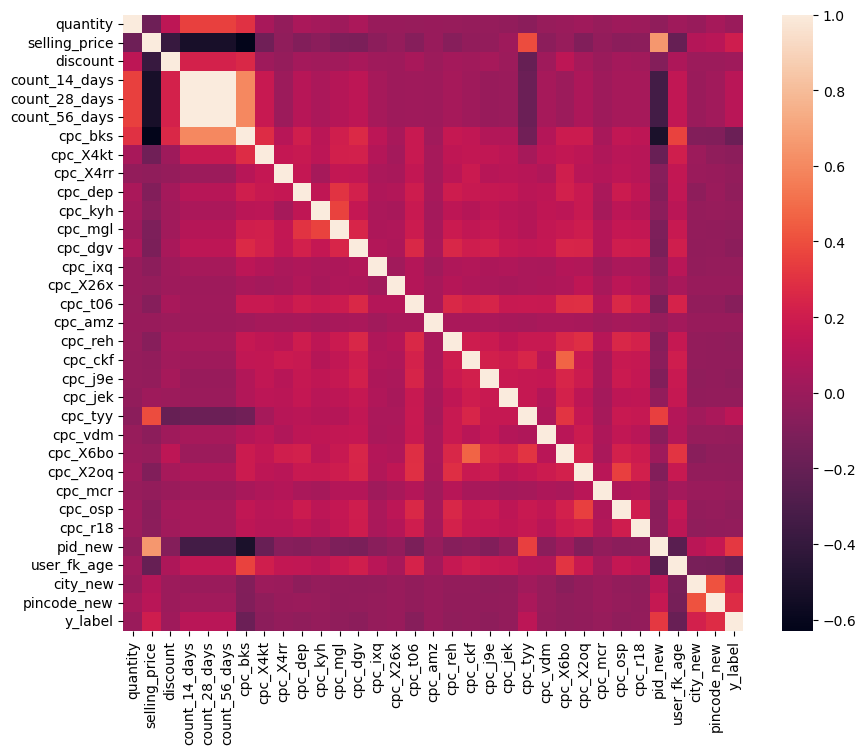

In [38]:
spearman_corr = raw_num_data.corr(method = 'spearman')

plt.figure(figsize=(10,8))
sns.heatmap(spearman_corr)
plt.show()

In [39]:
spearman_corr['y_label'].iloc[:-1]

quantity        -0.002603
selling_price    0.203549
discount         0.017548
count_14_days    0.110044
count_28_days    0.110044
count_56_days    0.110044
cpc_bks         -0.179601
cpc_X4kt        -0.051979
cpc_X4rr        -0.028901
cpc_dep         -0.040512
cpc_kyh         -0.021186
cpc_mgl         -0.040669
cpc_dgv         -0.050786
cpc_ixq         -0.024075
cpc_X26x        -0.010396
cpc_t06         -0.071202
cpc_amz         -0.006197
cpc_reh         -0.041888
cpc_ckf         -0.036713
cpc_j9e         -0.047511
cpc_jek         -0.029867
cpc_tyy          0.125783
cpc_vdm         -0.020690
cpc_X6bo        -0.038160
cpc_X2oq        -0.032129
cpc_mcr         -0.013080
cpc_osp         -0.041028
cpc_r18         -0.029896
pid_new          0.324441
user_fk_age     -0.192528
city_new         0.220881
pincode_new      0.275955
Name: y_label, dtype: float64

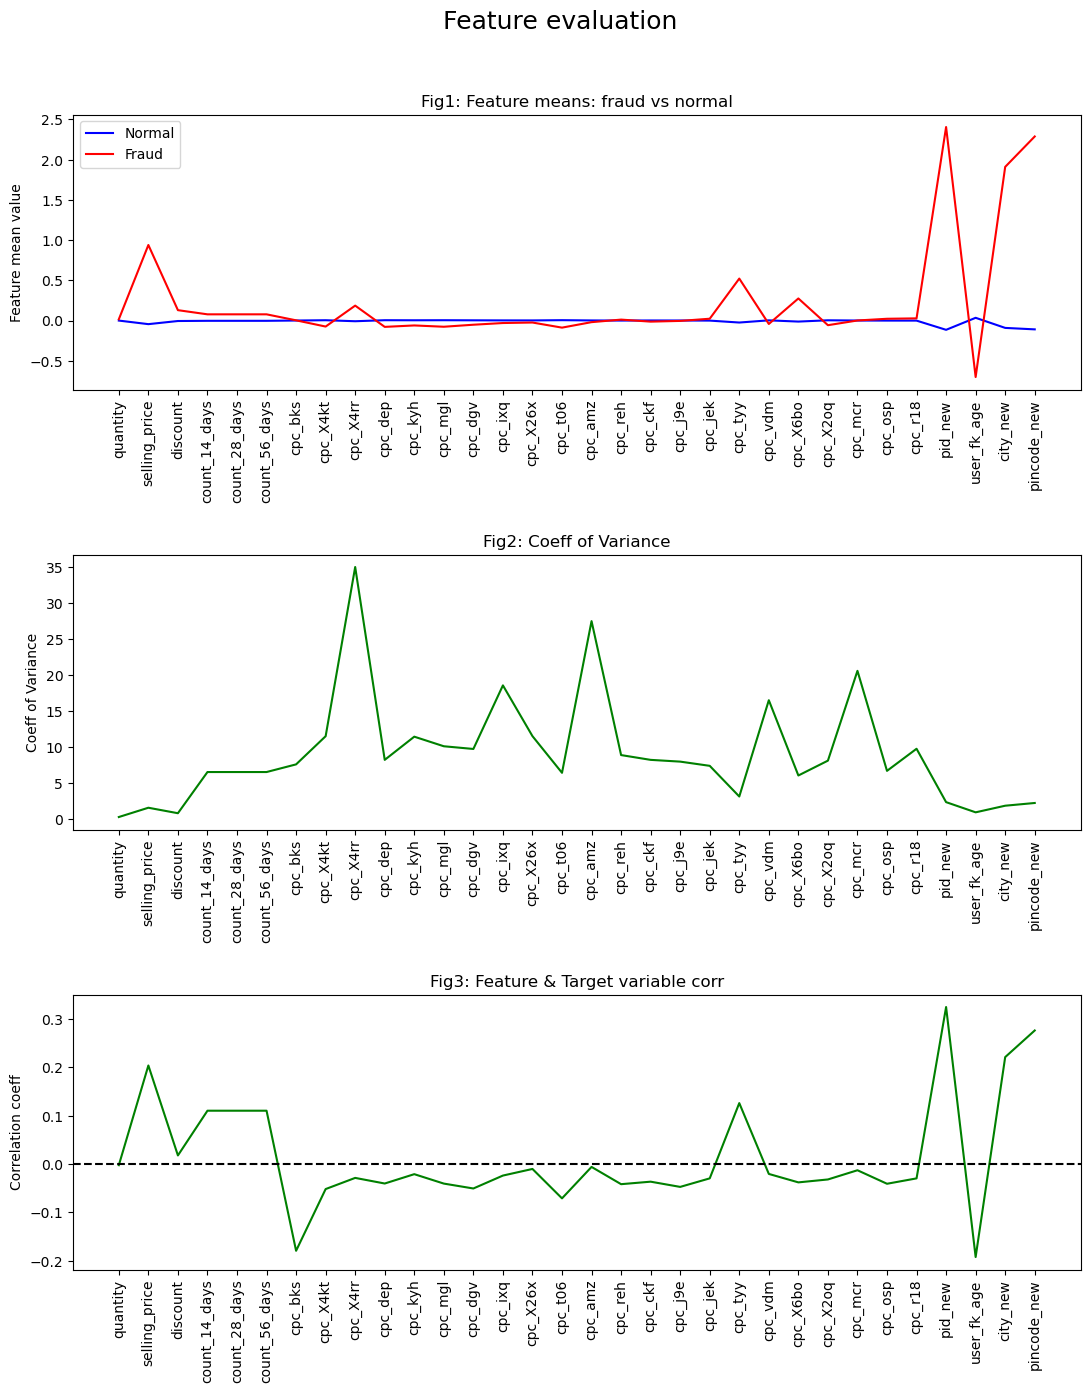

In [42]:
# Plotting the following 3 graphs for feature evaluation:
# 1. Feature wise mean for fraud vs normal orders
# 2. Coefficient of variance for each feature
# 3. Spearman corr. coeff of each feature with the target label

raw_num_data = raw_num_data.drop('y_label', axis=1)

# Scaling the data to ensure all feature means can be viewed on the same plot
temp_scaler = StandardScaler()
raw_num_scaled = pd.DataFrame(temp_scaler.fit_transform(raw_num_data), columns = raw_num_data.columns)

mean_fraud = raw_num_scaled[(raw_data.y_label == 1)].mean()
mean_normal = raw_num_scaled[(raw_data.y_label == 0)].mean()
feature_num = np.arange(1,raw_num_scaled.shape[1]+1,1)

# Figure to capture all three 
fig = plt.figure(figsize = (13,15))
fig.subplots_adjust(hspace = 0.6)
fig.suptitle('Feature evaluation', fontsize = 18, y = 0.95)
axs = fig.subplots(3,1)

axs[0].plot(feature_num, mean_normal, color = 'b', label = 'Normal')
axs[0].plot(feature_num, mean_fraud, color = 'r', label = 'Fraud')
axs[0].set(ylabel = 'Feature mean value', title = 'Fig1: Feature means: fraud vs normal')
axs[0].set_xticks(feature_num)
axs[0].set_xticklabels(raw_num_scaled.columns, rotation=90)
axs[0].legend()

feature_std = raw_num_data.std()
axs[1].plot(feature_num, feature_std/abs(raw_num_data.mean()), color = 'g')
axs[1].set(ylabel = 'Coeff of Variance', title = 'Fig2: Coeff of Variance')
axs[1].set_xticks(feature_num)
axs[1].set_xticklabels(raw_num_scaled.columns, rotation=90)

axs[2].plot(feature_num, spearman_corr['y_label'].iloc[:-1], color = 'g')
axs[2].set(ylabel = 'Correlation coeff', title = 'Fig3: Feature & Target variable corr')
axs[2].axhline(y=0, color='k', linestyle='--')
axs[2].set_xticks(feature_num)
axs[2].set_xticklabels(raw_num_scaled.columns, rotation=90)

a = 3 # Ignore

In [44]:
print(raw_data.columns)

Index(['order_id', 'product_id', 'quantity', 'selling_price', 'order_date',
       'shipping_type', 'user_id', 'user_account_created_date', 'address_id',
       'city', 'pincode', 'phone', 'vertical', 'discount', 'count_14_days',
       'count_28_days', 'count_56_days', 'cpc_bks', 'cpc_X4kt', 'cpc_X4rr',
       'cpc_dep', 'cpc_kyh', 'cpc_mgl', 'cpc_dgv', 'cpc_ixq', 'cpc_X26x',
       'cpc_t06', 'cpc_amz', 'cpc_reh', 'cpc_ckf', 'cpc_j9e', 'cpc_jek',
       'cpc_tyy', 'cpc_vdm', 'cpc_X6bo', 'cpc_X2oq', 'cpc_mcr', 'cpc_osp',
       'cpc_r18', 'label', 'y_label', 'pid_new', 'weekday', 'Monday',
       'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday',
       'is_ndd', 'user_fk_age', 'city_new', 'pincode_new', 'vert1', 'vert2',
       'vert3', 'vert4', 'vert5', 'vert6', 'vert7', 'vert8', 'vert9', 'vert10',
       'vert11', 'vert12', 'vert13', 'vert14', 'vert15', 'vert16', 'vert17',
       'vert18', 'vert19', 'vert20', 'vert21', 'vert22', 'vert23', 'vert24',
       'vert25',

In [49]:
data_processed = raw_data[['product_id', 'city', 'pincode', 'vertical', 'pid_new', 'city_new', 'pincode_new', 'quantity', 'selling_price', \
       'is_ndd', 'discount', 'count_56_days', 'user_fk_age', \
       'cpc_bks', 'cpc_X4kt', 'cpc_X4rr', \
       'cpc_dep', 'cpc_kyh', 'cpc_mgl', 'cpc_dgv', 'cpc_ixq', 'cpc_X26x', \
       'cpc_t06', 'cpc_amz', 'cpc_reh', 'cpc_ckf', 'cpc_j9e', 'cpc_jek', \
       'cpc_tyy', 'cpc_vdm', 'cpc_X6bo', 'cpc_X2oq', 'cpc_mcr', 'cpc_osp', \
       'cpc_r18', \
       'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday', \
       'vert1', 'vert2', 'vert3', 'vert4', 'vert5', 'vert6', 'vert7', 'vert8', 'vert9', 'vert10', \
       'vert11', 'vert12', 'vert13', 'vert14', 'vert15', 'vert16', 'vert17', \
       'vert18', 'vert19', 'vert20', 'vert21', 'vert22', 'vert23', 'vert24', \
       'vert25', 'vert26', 'vert27', 'vert28', 'vert29', 'vert30', 'vert31', \
       'vert32', 'vert33', 'vert34', 'vert35', 'vert36', 'vert37', 'vert38', \
       'vert39', 'vert40', 'vert41', 'vert42', 'vert43', 'vert44', 'vert45', \
       'vert46', 'y_label']]

<p style='font-size:16px'><b> 4.2) Inferences </b></p>
<p>


1) The Spearman corr coeff between count_14_days, count_28_days, count_56_days is ~1, implying they are significantly dependent.
2) The pid_new feature has highest correlation with the target variable - this is due to target encoding, but also implies that there are particular products more likely for fraud orders. The same can be seen in the city & pincode target encoded features.
3) The quantity feature has no difference in avg value for mean vs normal orders. It also has a low coeff of variance & low correlation with the target variable.
4) The average user_fk_age for normal users is much higher than for fraud users & also has a significant negative correlation with the target variable.
5) Fraud users have high purchase patterns in particular categories for e.g x4RR, tty, X6bo
6) The fraud orders have a significantly higher average selling price compared to normal orders.

Based on above observations, dropped the count_14_days, count_28_days features to create the final processed dataset. <br>
We can also filter out multiple features below a threshold of coeff of variance. However will include it for now but will evaluate it's contribution post modelling. <br>

</p>


<p style='font-size:16px'><b> 5) Train test split </b></p>

In [51]:
train, test = train_test_split(data_processed, train_size = 0.8)

In [53]:
train_group = pd.DataFrame(train.groupby('y_label').size(), columns = ['num_train_pts'])
train_group['%_train_pts'] = round(100*train_group.num_train_pts/train_group.num_train_pts.sum(),1)

test_group = pd.DataFrame(test.groupby('y_label').size(), columns = ['num_test_pts'])
test_group['%_test_pts'] = round(100*test_group.num_test_pts/test_group.num_test_pts.sum(),1)

print(train_group)
print("\n", test_group)

         num_train_pts  %_train_pts
y_label                            
0               367249         95.4
1                17636          4.6

          num_test_pts  %_test_pts
y_label                          
0               91778        95.4
1                4444         4.6


In [55]:
try:
    train.to_csv('dataset/train_data.csv', mode = 'x', index = False)
except:
    print("File already saved?")

try:
    test.to_csv('dataset/test_data.csv', mode = 'x', index = False)
except:
    print("File already saved?")